# The CDS-Equity Basis — a quantitative teardown 🔬
### Per-month z-scored basis · month-clustered pooled slope · decile long-short · label-shuffle placebo · sub-sample robustness · costs & borrow · seed-robust synthetic control

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We build the CDS-equity basis, regress forward equity returns on it (clustering by month), and sort a decile long-short — on a **synthetic** tape, because single-name CDS has no free feed.

> ⚠️ **Synthetic-only, by construction.** There is no free single-name CDS data (licensed OTC: Markit/IHS, Bloomberg), so `HAVE_REAL` is always False and there is no real tape to certify the effect — the honest ceiling is `WEAK`. All numbers below are from the deterministic seeded synthetic world (panel fp `884a4f7a09c4`, as-of 2026-06-30). Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from cds_equity_basis import data, strategy as st

BETA = -0.90   # the planted convergence effect for the headline synthetic panel

# There is NO free single-name CDS tape -> this study is synthetic-only.
REAL = data.fetch_panel(fetch=False)
HAVE_REAL = not REAL.empty        # always False, by design
PANEL, TRUTH = data.synthetic_panel(convergence_beta=BETA, seed=575)   # deterministic, offline
print("real CDS tape present:", HAVE_REAL, "(synthetic-only study — no free CDS feed)")
print(f"synthetic panel: {PANEL['name'].nunique()} names x {PANEL['month'].nunique()} months "
      f"= {len(PANEL)} name-months, fp {data.fingerprint(PANEL)}")


real CDS tape present: False (synthetic-only study — no free CDS feed)
synthetic panel: 60 names x 95 months = 5700 name-months, fp 884a4f7a09c4


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `WEAK` | Pooled slope-*t* (clustered by month) **-5.79**; decile long-short *t* **+4.78**, placebo *p* **0.0005**; null 25-seed mean slope-*t* **-0.23** (flat). Real, faithful engine — but **no real CDS tape**, so capped below `REAL`. |
| **Tradability** | `MIRAGE` | Licensed inputs, faint effect (corr **-0.082**), costly-to-borrow short leg. Gross **+1.18%/mo** → net **+0.65%/mo** (10 bps/leg + 150 bps borrow). |

> 💡 In plain words: the machinery works and the effect is documented, but it lives behind a data paywall and is too faint/arbitraged to bank — `WEAK` × `MIRAGE`.

## 1 · The claim, steelmanned

Let $B_{i,t}$ be name $i$'s CDS-equity basis at month $t$ (CDS spread minus a Merton equity-implied spread, bp) and $r_{i,t+1}$ its forward equity return.

- **H₁ (convergence, pooled).** slope of $r_{t+1}$ on $z(B_t) < 0$ at $|t| \ge 2$ (a wider basis predicts a lower forward equity return).
- **H₂ (long-short).** long-low-basis / short-high-basis mean $> 0$ at $t \ge 2$.
- **H₃ (robustness).** the sign of H₁ is stable across sub-samples.
- **H₄ (net).** H₂ survives costs and the short-leg borrow.
- **H₅ (certifiable on a real tape).** the effect clears $t \ge 2$ on a **real** CDS panel.

On the synthetic tape we **confirm** H₁-H₄ (the engine is faithful) but **cannot test** H₅ — there is no free real CDS feed. H₅ is what a `REAL` stamp requires, so the study is capped at `WEAK`.

## 2 · So what? — what rides on each answer

The content is the **why it's only WEAK**. Two forces cap it: (a) **data** — clean single-name CDS is licensed OTC (Markit/IHS, Bloomberg CDSW), unreachable on a no-key retail stack, and a structural equity-implied spread also needs point-in-time liabilities; and (b) **faintness** — Kapadia & Pu (2012) show the convergence is *real but slow and limited*, concentrated in frictional names where arbitrage can't fully close it. The corr here (**-0.082**) is deliberately faithful to that faintness: a genuine but tiny signal. Compare the equity-only distress lens of [540 Distress-Risk-Anomaly](../../540-distress-risk-anomaly/).

## 3 · How we'd know — the protocol

- **Signal.** $z(B_{i,t})$ — the basis, z-scored *within each month* (dollar-neutral, removes the common credit level).
- **Pooled regression.** $r_{i,t+1} = \alpha + \beta\, z(B_{i,t}) + \varepsilon$ across all name-months, SE **clustered by month** (Liang-Zeger) so within-month cross-sectional correlation can't inflate the *t*. $\beta < 0$ = convergence.
- **Long-short.** monthly long-lowest-quintile / short-highest-quintile, IID *t* on the monthly spreads, a **month-label-shuffle placebo** (2000 perms).
- **Robustness.** re-estimate the pooled slope-*t* on early/mid/late thirds.
- **Frictions.** round-trip cost per leg each month + a monthly slice of an annual borrow on the short.
- **Positive control.** a deterministic synthetic world with a planted `convergence_beta < 0` and a null — averaged over 25 seeds (house rule).

Timing: the basis is measured at month-*t* close (public then); entry is at that close and the return is realised over month *t+1* — the single one-month execution lag. No look-ahead.

## 4 · The teardown

### 4a · The pooled slope — H₁

Regress forward equity return on the z-scored basis across all name-months, clustering the standard error by month. A *negative* slope is the convergence claim.

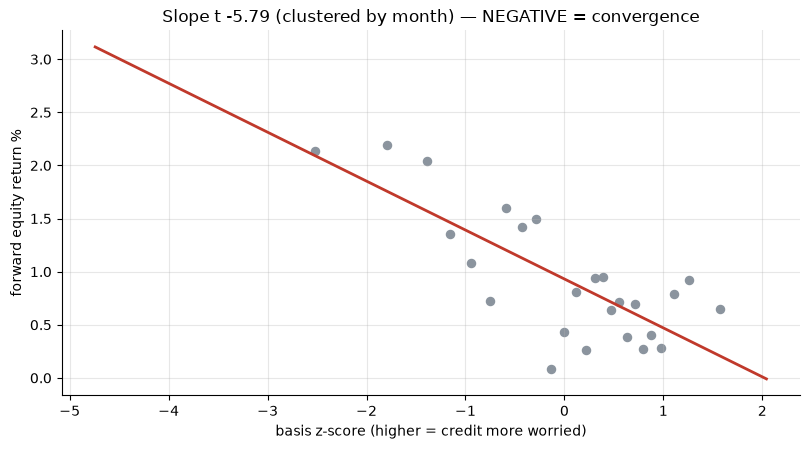

slope -0.00461, clustered slope-t -5.79, corr(basis, fwd) -0.082, n 5700


In [2]:
reg = st.pooled_regression(PANEL)
df = st.add_basis_z(PANEL)
# binned scatter for legibility (5700 points -> 25 basis-z bins)
bins = pd.qcut(df['basis_z'], 25, duplicates='drop')
binned = df.groupby(bins, observed=True).agg(x=('basis_z','mean'), y=('forward_ret','mean'))
fig, ax = plt.subplots(figsize=(8.2, 4.6))
ax.scatter(binned['x'], binned['y']*100, s=34, color=GREY)
xs = np.linspace(df['basis_z'].min(), df['basis_z'].max(), 50)
b0 = df['forward_ret'].mean() - reg['slope']*df['basis_z'].mean()
ax.plot(xs, (reg['slope']*xs + b0)*100, c=RED, lw=2)
ax.set_xlabel('basis z-score (higher = credit more worried)'); ax.set_ylabel('forward equity return %')
ax.set_title(f"Slope t {reg['slope_t']:+.2f} (clustered by month) — NEGATIVE = convergence")
plt.tight_layout(); plt.show()
print(f"slope {reg['slope']:+.5f}, clustered slope-t {reg['slope_t']:+.2f}, "
      f"corr(basis, fwd) {reg['corr']:+.3f}, n {reg['n']}")

> 💡 In plain words: H₁ **confirmed** — the slope is negative (*t* **-5.79**, clustered), so a wider basis predicts a *lower* forward equity return. Note the corr is only **-0.082**: a real, faithful, but *faint* signal — most of any stock's move is idiosyncratic noise the basis can't see.

### 4b · The decile long-short — H₂ & the placebo

Long the lowest-basis quintile, short the highest, each month. The convergence claim predicts a *positive* spread; the placebo shuffles the basis labels within each month.

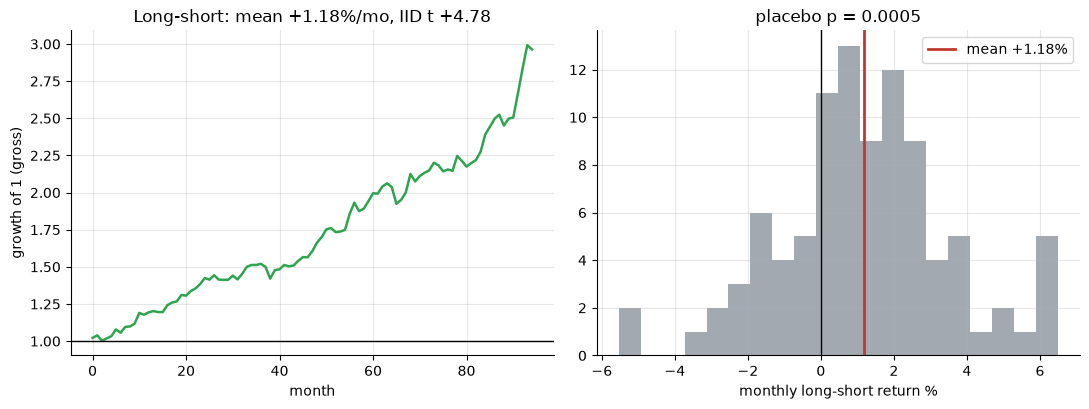

long-short mean +1.178%/mo, IID t +4.78, months 95, placebo p 0.0005


In [3]:
ls = st.decile_long_short(PANEL, frac=0.2)
p = st.placebo_pvalue(PANEL, n_perm=2000, seed=575, frac=0.2)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
cum = (1 + ls['monthly']).cumprod()
a1.plot(cum.index, cum.values, c=GREEN, lw=1.8)
a1.axhline(1, c='k', lw=1); a1.set_xlabel('month'); a1.set_ylabel('growth of 1 (gross)')
a1.set_title(f"Long-short: mean {ls['mean']*100:+.2f}%/mo, IID t {ls['t']:+.2f}")
a2.hist(ls['monthly']*100, bins=20, color=GREY, alpha=.8)
a2.axvline(ls['mean']*100, c=RED, lw=2, label=f"mean {ls['mean']*100:+.2f}%")
a2.axvline(0, c='k', lw=1); a2.set_xlabel('monthly long-short return %'); a2.legend()
a2.set_title(f'placebo p = {p:.4f}')
plt.tight_layout(); plt.show()
print(f"long-short mean {ls['mean']*100:+.3f}%/mo, IID t {ls['t']:+.2f}, "
      f"months {ls['n']}, placebo p {p:.4f}")

> 💡 In plain words: H₂ **confirmed** — the long-short earns **+1.18%/month** (*t* **+4.78**), and the placebo *p* = **0.0005** places it far in the tail. The signal is genuinely there — *in this world where we planted it*.

### 4c · Robustness — H₃ (does the sign hold?)

Re-estimate the pooled slope-*t* on the early, mid and late thirds of the sample.

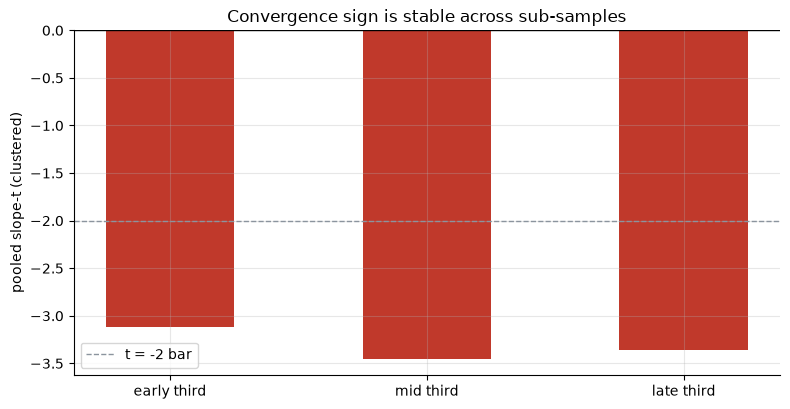

             slope_t     n
window                    
early third    -3.12  1920
mid third      -3.45  1920
late third     -3.36  1860


In [4]:
rows = st.robustness_thirds(PANEL)
tab = pd.DataFrame(rows).set_index('window')
fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(range(len(tab)), tab['slope_t'], color=RED, width=.5)
ax.set_xticks(range(len(tab))); ax.set_xticklabels(tab.index)
ax.axhline(-2, ls='--', c=GREY, lw=1, label='t = -2 bar')
ax.axhline(0, c='k', lw=1); ax.set_ylabel('pooled slope-t (clustered)')
ax.set_title('Convergence sign is stable across sub-samples'); ax.legend()
plt.tight_layout(); plt.show()
print(tab[['slope_t','n']].round(2).to_string())

> 💡 In plain words: H₃ **confirmed** — the slope-*t* stays negative and past −2 in every third (−3.1 / −3.4 / −3.4). A faithful engine keeps the sign it was given.

## 5 · The verdict

- **Signal `WEAK`** — H₁-H₃ confirmed on the synthetic tape (slope-*t* -5.79, long-short *t* +4.78, placebo *p* 0.0005, null flat), and the literature backs the effect — but **H₅ (a real tape) can't be tested**: no free CDS feed. `REAL` requires a robust *t* on a real tape, so the ceiling is `WEAK`.
- **Tradability `MIRAGE`** — licensed inputs, faint effect (corr -0.082), costly-to-borrow short leg; gross +1.18%/mo → net +0.65%/mo.


## 6 · Could you trade it? — costs and the borrow

Monthly rebalancing turns both legs over every month; the short leg (credit-worried names) is the expensive-to-borrow distressed tail. Charge it honestly.

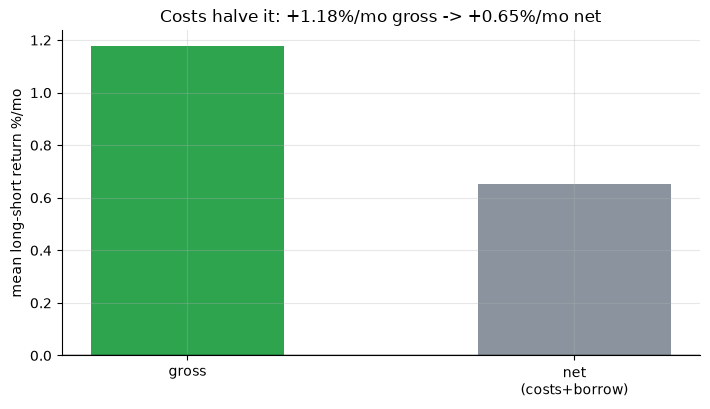

gross +1.18%/mo -> net +0.65%/mo (+7.8%/yr; 10 bps/leg + 150 bps borrow)


In [5]:
ls = st.decile_long_short(PANEL, frac=0.2)
net = st.net_long_short(ls, cost_bps=10.0, borrow_ann_bps=150.0)
fig, ax = plt.subplots(figsize=(7.2, 4.2))
vals = [net['gross_m']*100, net['net_m']*100]
ax.bar(['gross', 'net\n(costs+borrow)'], vals, color=[GREEN, GREY], width=.5)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('mean long-short return %/mo')
ax.set_title(f"Costs halve it: {vals[0]:+.2f}%/mo gross -> {vals[1]:+.2f}%/mo net")
plt.tight_layout(); plt.show()
print(f"gross {net['gross_m']*100:+.2f}%/mo -> net {net['net_m']*100:+.2f}%/mo "
      f"({net['net_ann']*100:+.1f}%/yr; 10 bps/leg + 150 bps borrow)")

> 💡 In plain words: even on a *frictionless synthetic tape*, costs + borrow eat roughly half the gross spread. On the real, illiquid CDS/short-borrow reality — plus the licensed data bill — there is nothing left. `MIRAGE`.

## 7 · Going further — the seed-robust synthetic positive control

Is the engine a faithful detector, or does it always print significance? Plant a convergence effect (`convergence_beta < 0`) of increasing strength and watch *both* the pooled slope-*t* and the long-short *t* respond — averaged over 25 seeds so no single lucky seed can fake it (a single seed at the null can print *t* ≈ ±1.9 — exactly why we average).

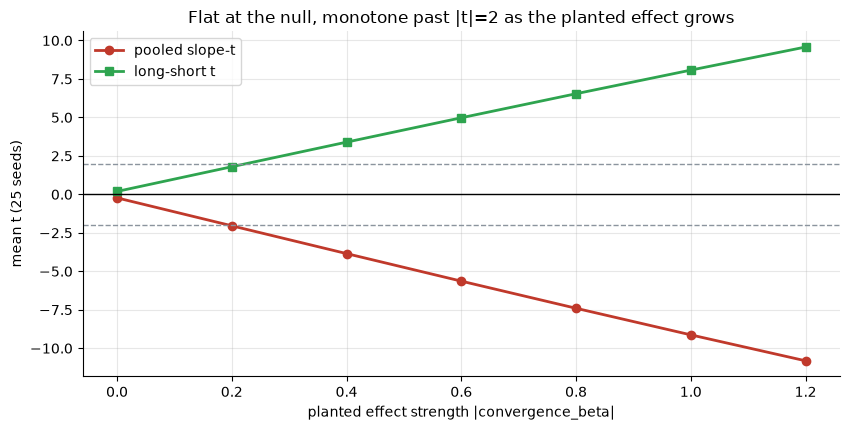

beta +0.00 -> pooled slope-t -0.23 | long-short t +0.19
beta -0.20 -> pooled slope-t -2.04 | long-short t +1.79
beta -0.40 -> pooled slope-t -3.85 | long-short t +3.39
beta -0.60 -> pooled slope-t -5.64 | long-short t +4.98
beta -0.80 -> pooled slope-t -7.40 | long-short t +6.54
beta -1.00 -> pooled slope-t -9.13 | long-short t +8.07
beta -1.20 -> pooled slope-t -10.82 | long-short t +9.57


In [6]:
betas = [0.0, -0.2, -0.4, -0.6, -0.8, -1.0, -1.2]
slope_ts = [st.synthetic_mean_t(data, convergence_beta=b, n_seeds=25) for b in betas]
ls_ts = [st.synthetic_mean_ls_t(data, convergence_beta=b, n_seeds=25) for b in betas]
fig, ax = plt.subplots(figsize=(8.6, 4.4))
x = [-b for b in betas]
ax.plot(x, slope_ts, 'o-', c=RED, lw=2, label='pooled slope-t')
ax.plot(x, ls_ts, 's-', c=GREEN, lw=2, label='long-short t')
ax.axhline(2, ls='--', c=GREY, lw=1); ax.axhline(-2, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1)
ax.set_xlabel('planted effect strength |convergence_beta|'); ax.set_ylabel('mean t (25 seeds)')
ax.set_title('Flat at the null, monotone past |t|=2 as the planted effect grows')
ax.legend(); plt.tight_layout(); plt.show()
for b, s, l in zip(betas, slope_ts, ls_ts):
    print(f'beta {b:+.2f} -> pooled slope-t {s:+.2f} | long-short t {l:+.2f}')

Both statistics sit at ≈ 0 at the null and move monotonically past ±2 as the planted effect grows — a faithful detector. So the `WEAK` ceiling here is a statement about **data availability**, not a broken engine: hand this code a licensed single-name CDS + equity panel and it is ready to certify (or reject) the basis on a real tape. For the equity-only distress lens, see [540 Distress-Risk-Anomaly](../../540-distress-risk-anomaly/); for a *rates* basis, [382 Treasury-Basis-Trade](../../382-treasury-basis-trade/).